# Supplementary Fig. 8c — mutational signatures of the reference-standard variant calls

The 96-context (trinucleotide) mutational signature of the DCS variant calls, for the undiluted **100 %
Horizon Myeloid Reference Standard** and for the **hDNA** (undiluted peripheral-blood DNA used as the
diluent), restricted to variants with VAF < 100 % and ≥ 500× DCS depth. These are panel **c** of the published Supplementary Fig. 8.

Each context's observed count is divided by that trinucleotide's frequency across the panel, so the signature reflects the per-site error rate rather than the panel's base composition.

## Data availability

The per-sample variant-call files read by this notebook are **not distributed with this code**. The
Myeloid Reference Standard is commercial material, but the hDNA sample is peripheral-blood DNA from a
single 65-year-old individual (the diluent used to make the dilution series), and these files report
reference and variant read depth at every panel position — which carries that individual's germline
genotypes.

The panel site list is not individual-level data and is included here.

The sequencing data for the Myeloid Reference Standard dilutions and the hDNA sample is **not
deposited**: the EGA submission covers the UKCTOCS participant samples only. These panels therefore cannot
be re-run from public data, and the code is included for transparency. (The observed VAFs of the validated
reference-standard variants are published separately, as **Table S1** of the paper.)

| path | contents | location |
|---|---|---|
| `*_DCS_variants_MUFs_3_annotated.txt`, `*_DCS_variants_MUFs_3_all_positions.vcf` | per-sample DCS variant calls (reference standard, dilutions, hDNA) | not distributed |
| `TWIST_SNV_panel_all_possible_changes_panel_sites.csv` | every panel site's trinucleotide context (pre-computed from hg19) | Data_files/Horizon_reference_standards |

The figures saved below are the output of a run with the call files in place.

The original notebook read the 2.9 GB `Homo_sapiens_assembly19.fasta` to derive each variant's trinucleotide
context; because that context is already cached per panel site in the CSV above, this version rebuilds it
from the CSV and needs no reference FASTA.

In [10]:
# imported packages
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [12]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
# yellow = '#ffffd4'

# Setup for analyses

In [13]:
changes = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G'] #group e.g. C>T and G>A togethe
complementary_changes = {'C>T':'G>A', 'C>A':'G>T', 'C>G':'G>C', 'T>C':'A>G', 'T>A':'A>T', 'T>G':'A>C',
                        'G>A':'C>T','G>T':'C>A', 'G>C':'C>G', 'A>G':'T>C','A>T':'T>A', 'A>C':'T>G'}

bases = ['A', 'C', 'G', 'T']
complementary_bases = {'C': 'G', 'G': 'C', 'T': 'A', 'A': 'T'}

In [14]:
# Make lists of all the possible trinucleotide context changes (so can iterate through them)
all_changes = []
alternate_changes = {} #make a dictionary of complementary trinucleotide changes

for i in changes:
    for first_base in bases:
        for second_base in bases:
            trinuc = first_base+'['+i+']'+second_base
            comp_trinuc = complementary_bases[second_base]+'['+complementary_changes[i]+']'+complementary_bases[first_base]
            all_changes.append(trinuc)
            alternate_changes[trinuc]=comp_trinuc
            alternate_changes[comp_trinuc]=trinuc
                
C_A_changes = all_changes[0:16]
C_G_changes = all_changes[16:32]
C_T_changes = all_changes[32:48]
T_A_changes = all_changes[48:64]
T_C_changes = all_changes[64:80]
T_G_changes = all_changes[80:96]

trinucleotide_changes=[C_A_changes, C_G_changes, C_T_changes, T_A_changes, T_C_changes, T_G_changes]

In [15]:
changes_color = {'C>T': "#fdcc8a", 'C>A':"#bdd7e7", 'C>G': "#cbc9e2", 'T>C': "#bae4b3", 'T>A': "#cccccc", 'T>G':"#fbb4b9"}
poisson_color = {'C>T': "#e6550d", 'C>A':"#08519c", 'C>G': "#54278f", 'T>C': "#006d2c", 'T>A': "#252525", 'T>G':"#c51b8a"}

# Calculate trinucleotide frequencies across panel

# File processing

In [16]:
all_TWIST_positions_df = pd.read_csv('Data_files/TWIST_SNV_panel_all_possible_changes_panel_sites.csv', usecols=[1, 2, 3, 4, 5, 6])

In [17]:
# --- trinucleotide context WITHOUT the reference genome ---
# `all_TWIST_positions_df` (read above) has, for every panel site, its trinucleotide context in the
# 5'[ref>alt]3' form (e.g. 'A[C>A]C') — these were generated from Homo_sapiens_assembly19.fasta. We rebuild
# the per-position 5'/3' flanking bases and the panel trinucleotide frequencies directly from it, so this
# notebook reproduces the mutational signatures without needing the reference FASTA.
from collections import Counter as _Counter

_flank = {}
_trinuc_counter = _Counter()
for _row in all_TWIST_positions_df.itertuples(index=False):
    _tc = _row.trinucleotide                       # '5'[ref>alt]3'', e.g. 'A[C>A]C'
    _flank[(_row.chromosome, _row.position)] = (_tc[0], _tc[6])
    _trinuc_counter[_tc[0] + _tc[2] + _tc[6]] += 1  # 5'+ref+3', e.g. 'ACC'

def five_prime(chromosome, position):
    return _flank.get((chromosome, position), ('N', 'N'))[0]

def three_prime(chromosome, position):
    return _flank.get((chromosome, position), ('N', 'N'))[1]

# panel trinucleotide frequencies (each site appears once per alt base in the CSV; the ratio is unchanged)
_total_trinuc = sum(_trinuc_counter.values())
trinucleotide_frequencies_panel = {k: v / _total_trinuc for k, v in _trinuc_counter.items()}

In [18]:
def expand_info_depth(info):
    info_split = info.split(';')
    try:
        depth = info_split[2].split('=')[1]
    except IndexError:
        print(info)
    var_depth = info_split[4].split('=')[1]
    return depth

def expand_info_variant_depth(info):
    info_split = info.split(';')
    depth = info_split[2].split('=')[1]
    var_depth = info_split[4].split('=')[1]
    return var_depth

In [19]:
def change(info):
    info_split = info.split(';')
    depth = info_split[2].split('=')[1]
    var_depth = info_split[4].split('=')[1]
    return var_depth

In [20]:
all_sample_names = ['Myeloid_0_1A', 'Myeloid_0_1B', 'Myeloid_1A', 'Myeloid_1B', 'Myeloid_10A', 'Myeloid_10B', 'Myeloid_100A', 'Myeloid_100B', 'SEM11503A', 'SEM11503B']
dilutions_names = ['Myeloid_0_1A', 'Myeloid_0_1B', 'Myeloid_1A', 'Myeloid_1B', 'Myeloid_10A', 'Myeloid_10B', 'Myeloid_100A', 'Myeloid_100B']
hDNA_names = ['SEM11503A', 'SEM11503B']
myeloid_names = ['Myeloid_100A', 'Myeloid_100B']

In [21]:
def create_sample_df_with_names_with_filters(sample_name, overall_df, DCS_or_SSCS):
    
    txt_path = 'Data_files/Horizon_reference_standards/'+sample_name+'_SNV_SNV_watson_code_'+DCS_or_SSCS+'_variants_MUFs_3_annotated.txt'
    
    df = pd.read_csv(txt_path, delimiter = '\t', usecols=["chromosome", "start", "end", "REF", "ALT", "total_depth", "variant_depth", "variant_type",
                                                         "RSID", "variant_mean_UMI_family_size",
                                                          "mean_position_in_read", "strand_bias_fisher_p_value_phred", "exac_all"])
    df[sample_name+'_depth']=df['total_depth']
    df[sample_name+'_var_depth']=df['variant_depth']
    df['change']=df['REF']+'>'+df['ALT']
    df['position'] = pd.to_numeric(df['start'])
    df['five_prime'] = df.apply(lambda x: five_prime(x.chromosome, x.position), axis=1)
    df['three_prime'] = df.apply(lambda x: three_prime(x.chromosome, x.position), axis=1)
    df['trinucleotide']=df['five_prime']+'['+df['change']+']'+df['three_prime']
    df['exac_all'] = df['exac_all'].replace(to_replace='.', value=0)
    df = df.fillna(0)

    df['strand_bias_fisher_p_value_phred'] = df['strand_bias_fisher_p_value_phred'].astype('float')
    df['exac_all'] = df['exac_all'].astype('float')

    ##filters
    df = df[df['RSID']=='-']
    df = df[df['mean_position_in_read']>= 8]
    df = df[df['exac_all']<= 0.01]
    df = df[df['strand_bias_fisher_p_value_phred']< 60]
    df = df[df['variant_mean_UMI_family_size']> 2]
    df = df[df['REF'].str.len() ==1]
    df = df[df['ALT'].str.len() ==1]

    df = df[['chromosome', 'position', 'REF', 'ALT', 'change', 'trinucleotide', sample_name+'_depth', sample_name+'_var_depth']]

    df[sample_name]=df[sample_name+'_var_depth'].apply(str)+','+df[sample_name+'_depth'].apply(str)+','+sample_name
    
    df2 = df[['chromosome', 'position', 'REF', 'ALT', 'change', 'trinucleotide', sample_name]]

    merged_df2 = pd.merge(overall_df, df2, how="left", on=["chromosome", "position", "REF", "ALT", "change", "trinucleotide"])
    merged_df2 = merged_df2.fillna(0)
    merged_df2 = merged_df2.sort_values(['chromosome', 'position'], ascending=[True, True])
    
    return merged_df2

In [22]:
def create_sample_df_with_names(sample_name, overall_df, DCS_or_SSCS):
    
    vcf_path = 'Data_files/Horizon_reference_standards/'+sample_name+'_SNV_SNV_watson_code_'+DCS_or_SSCS+'_variants_MUFs_3_all_positions.vcf'
    
    if DCS_or_SSCS == 'SSCS':
        colnames = ['chromosome', 'position', 'ID', 'ref', 'alt', 'QUAL', 'FILTER', 'INFO']
    if DCS_or_SSCS == 'DCS':
        colnames = ['chromosome', 'position', 'ID', 'ref', 'alt', 'FILTER', 'INFO']
        
    df = pd.read_csv(vcf_path, index_col=False, delimiter = '\t', comment='#', names=colnames) #'comment='#' ignores the rows that start with #
    df = df[df['alt']!='-']
    df[sample_name+'_depth']=df['INFO'].apply(expand_info_depth)
    df[sample_name+'_var_depth']=df['INFO'].apply(expand_info_variant_depth)
    df['change']=df['ref']+'>'+df['alt']
    df['position'] = pd.to_numeric(df['position'])
    df['three_prime'] = df.apply(lambda x: three_prime(x.chromosome, x.position), axis=1)
    df['five_prime'] = df.apply(lambda x: five_prime(x.chromosome, x.position), axis=1)
    df['trinucleotide']=df['five_prime']+'['+df['change']+']'+df['three_prime']
    df = df[['chromosome', 'position', 'ref', 'alt', 'change', 'trinucleotide', sample_name+'_depth', sample_name+'_var_depth']]
    df = df[df['ref'].str.len() ==1]
    df = df[df['alt'].str.len() ==1]
    df = df.fillna(0)
    
    df[sample_name]=df[sample_name+'_var_depth']+','+df[sample_name+'_depth']+','+sample_name
    
    df2 = df[['chromosome', 'position', 'ref', 'alt', 'change', 'trinucleotide', sample_name]]

    merged_df2 = pd.merge(overall_df, df2, how="left", on=["chromosome", "position", "ref", "alt", "change", "trinucleotide"])
    merged_df2 = merged_df2.fillna(0)
    merged_df2 = merged_df2.sort_values(['chromosome', 'position'], ascending=[True, True])
    
    return merged_df2

In [23]:
def create_combined_dataframes(all_sample_names, dilution_names, myeloid_names, hDNA_names, DCS_or_SSCS):
    # Create a dataframe containing the total depth and variant depth of each sample at every position
    combined_df2 = all_TWIST_positions_df.copy()
    for sample_name in all_sample_names:
        new_df2 = create_sample_df_with_names(sample_name, combined_df2, DCS_or_SSCS)
        combined_df2 = new_df2
        
    dilution_combined_df2 = all_TWIST_positions_df.copy()
    for sample_name in dilution_names:
        dilution_new_df2 = create_sample_df_with_names(sample_name, dilution_combined_df2, DCS_or_SSCS)
        dilution_combined_df2 = dilution_new_df2

    myeloid_combined_df2 = all_TWIST_positions_df.copy()
    for sample_name in myeloid_names:
        myeloid_new_df2 = create_sample_df_with_names(sample_name, myeloid_combined_df2, DCS_or_SSCS)
        myeloid_combined_df2 = myeloid_new_df2

    hDNA_combined_df2 = all_TWIST_positions_df.copy()
    for sample_name in hDNA_names:
        hDNA_new_df2 = create_sample_df_with_names(sample_name, hDNA_combined_df2, DCS_or_SSCS)
        hDNA_combined_df2 = hDNA_new_df2
        
    return combined_df2, dilution_combined_df2, myeloid_combined_df2, hDNA_combined_df2

In [24]:
def create_combined_dataframes_with_filters(all_sample_names, dilution_names, myeloid_names, hDNA_names, DCS_or_SSCS):
    # Create a dataframe containing the total depth and variant depth of each sample at every position
    
    all_TWIST_positions_df2 = all_TWIST_positions_df.copy().rename(columns={"ref": "REF", "alt": "ALT"})
    
    combined_df2 = all_TWIST_positions_df2.copy()
    for sample_name in all_sample_names:
        new_df2 = create_sample_df_with_names_with_filters(sample_name, combined_df2, DCS_or_SSCS)
        combined_df2 = new_df2
        
    dilution_combined_df2 = all_TWIST_positions_df2.copy()
    for sample_name in dilution_names:
        dilution_new_df2 = create_sample_df_with_names_with_filters(sample_name, dilution_combined_df2, DCS_or_SSCS)
        dilution_combined_df2 = dilution_new_df2

    myeloid_combined_df2 = all_TWIST_positions_df2.copy()
    for sample_name in myeloid_names:
        myeloid_new_df2 = create_sample_df_with_names_with_filters(sample_name, myeloid_combined_df2, DCS_or_SSCS)
        myeloid_combined_df2 = myeloid_new_df2

    hDNA_combined_df2 = all_TWIST_positions_df2.copy()
    for sample_name in hDNA_names:
        hDNA_new_df2 = create_sample_df_with_names_with_filters(sample_name, hDNA_combined_df2, DCS_or_SSCS)
        hDNA_combined_df2 = hDNA_new_df2
        
    return combined_df2, dilution_combined_df2, myeloid_combined_df2, hDNA_combined_df2

In [25]:
DCS_all, DCS_dilutions, DCS_myeloid, DCS_hDNA = create_combined_dataframes_with_filters(all_sample_names, dilutions_names, myeloid_names, hDNA_names, 'DCS')
# SSCS_all, SSCS_dilutions, SSCS_myeloid, SSCS_hDNA = create_combined_dataframes_with_filters(all_sample_names, dilutions_names, myeloid_names, hDNA_names, 'SSCS')

In [26]:
def total_variant_count(df, VAF_CUT, minimum_depth):
    count = 0
    for position in df.values.tolist():
        for sample in position[6:]:
            if sample != 0:
                var_depth = int(sample.split(',')[0])
                tot_depth = int(sample.split(',')[1])
                if tot_depth >= minimum_depth and var_depth >= 1 and var_depth < VAF_CUT * tot_depth:
                    count += 1
    return count

n_hDNA    = total_variant_count(DCS_hDNA, 1.0, 500)
n_myeloid = total_variant_count(DCS_myeloid, 1.0, 500)
print('hDNA n =', n_hDNA)
print('myeloid n =', n_myeloid)

hDNA n = 7988
myeloid n = 7421


# Mutational signatures

In [ ]:
def normalised_trinucleotide_count(df, trinucleotide_change, VAF_CUT, minimum_depth):
    
    complementary_trinucleotide = alternate_changes[trinucleotide_change]
    tri_df = df[(df['trinucleotide']==trinucleotide_change) | (df['trinucleotide']==complementary_trinucleotide)] #just look at positions that are trinucleotide context (or complement) of interest
    data_values = tri_df.values.tolist() #create a list of the depths at all the positions of interest

    trinucleotide_count = 0

    for position in data_values:
        chromosome = position[0]
        pos = position[1]
        ref = position[2]
        alt = position[3]

        for sample in position[6:]:
            if sample !=0:
                var_depth = int(sample.split(',')[0])
                tot_depth = int(sample.split(',')[1])
                sample_ID = sample.split(',')[2]

                if tot_depth >= minimum_depth:
                    if var_depth >=1:
                        if var_depth < VAF_CUT*tot_depth: #i.e. ignore samples at that position that have VAFs > cut-off
                            trinucleotide_count+=1

    trio = trinucleotide_change[0]+trinucleotide_change[2]+trinucleotide_change[6] #i.e. C[A>T]T > CAT
    complementary_trio = complementary_trinucleotide[0]+complementary_trinucleotide[2]+complementary_trinucleotide[6] #i.e. A[T>A]G > ATG
    trinucleotide_frequency = trinucleotide_frequencies_panel[trio]+trinucleotide_frequencies_panel[complementary_trio]
    normalised_count = trinucleotide_count/trinucleotide_frequency
    
    return normalised_count

In [28]:
changes_color = {'C>T': "#ef3b2c", 'C>A':"#9ecae1", 'C>G': "#252525", 'T>C': "#a1d99b", 'T>A': "#d9d9d9", 'T>G':"#fcc5c0"}

In [29]:
def mutational_signature(df, SSCS_or_DCS, VAF_CUT, min_depth, sample_description):
    
    trinucleotide_frequency_count = {}

    for change in trinucleotide_changes: #[[A[C>T]A, A[C>T]C.,..], [A[A>C]A, A[C>A]C...].. (the 'change' is all C>T changes)
        for i in change:
            trinucleotide_frequency_count[i]=normalised_trinucleotide_count(df, i, VAF_CUT, min_depth)
    
    fig = plt.figure(figsize=(27, 7))
    gs = matplotlib.gridspec.GridSpec(2, 1, width_ratios=[1], height_ratios=[1,15])
    ax1 = plt.subplot(gs[1])
    ax2 = plt.subplot(gs[0])
    gs.update(hspace=0.05)

    x = []
    y = []
    colors = []

    for k, v in trinucleotide_frequency_count.items():
        x.append(k)
        y.append(v)
        change = k[2:5]
        color = changes_color[change]
        colors.append(color)

    ax1.bar(x, y, color = colors)

    ax1.set_xlim(-1, 96)
    ax2.set_xlim(0, 97)

    # Axis labels
    ax1.set_xlabel('trinucleotide context of base change', fontsize = 20, labelpad = 12, fontweight = 'medium')
    ax1.set_ylabel('normalised count', fontsize = 20, labelpad = 6, fontweight = 'medium')

    ax1.tick_params(axis='x', labelrotation = 90, labelsize = 13)
    ax1.tick_params(axis='y', labelsize = 16)

    ax1.xaxis.set_tick_params(width=1, color = grey3, length = 6)
    ax1.yaxis.set_tick_params(width=1, color = grey3, length = 6)

    #Only show the required axis lines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(1.5)
        ax1.spines[axis].set_color(grey3)

    #plot the bar chart at the top
    colors2 = [changes_color['C>A'], changes_color['C>G'], changes_color['C>T'], 
               changes_color['T>A'], changes_color['T>C'], changes_color['T>G']]
    values = np.array([16, 16, 16, 16, 16, 16])
    lefts = np.array([0.5, 16.5, 32.5, 48.5, 64.5, 80.5])
    names = np.array(['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G'])
    for value, left, color, name in zip(values, lefts, colors2, names):
        ax2.bar(x=left, height=-10, width=value, bottom=-5, color=color, orientation = 'horizontal', label = name, edgecolor='k', linewidth=1)
        ax2.text(left + (value/2.), (7), name, ha='center', va='center', fontsize = 20)

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    x2_major_tick_labels = [""]
    y2_major_tick_labels = [""]
    ax2.set_xticklabels(x2_major_tick_labels)
    ax2.set_yticklabels(y2_major_tick_labels)

    ax2.xaxis.set_tick_params(width=0, color = 'white', length = 0)
    ax2.yaxis.set_tick_params(width=0, color = 'white', length = 0)

    if VAF_CUT>=0.01:
        ax1.text(0.99, 0.94, 'VAFs < '+str(int((VAF_CUT*100)))+' %', horizontalalignment='right', fontsize = 16, transform=ax1.transAxes,
                bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round, pad=0.5'))
    else:
        ax1.text(0.99, 0.94, 'VAFs < '+str((VAF_CUT*100))+' %', horizontalalignment='right', fontsize = 16, transform=ax1.transAxes,
                bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round, pad=0.5')) 

    sample_description_text = sample_description.replace('_', ' ')
        
    ax1.text(0.01, 0.84, SSCS_or_DCS, horizontalalignment='left', fontsize = 16, transform=ax1.transAxes,
            bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round, pad=0.5'))
    ax1.text(0.01, 0.94, sample_description_text, horizontalalignment='left', fontsize = 16, transform=ax1.transAxes,
            bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round, pad=0.5'))

    if (VAF_CUT*100>=1) and ((VAF_CUT*100) %1 == 0):
        VAF_save = str(int(VAF_CUT*100))
    else:
        VAF_save = str(VAF_CUT*100).replace('.', '_')

    plt.tight_layout()

    return plt.show()

### Supplementary Fig. 8c - Mutational signatures for hDNA (undiluted) and 100% Myeloid reference standard

#### 100% myeloid reference standard

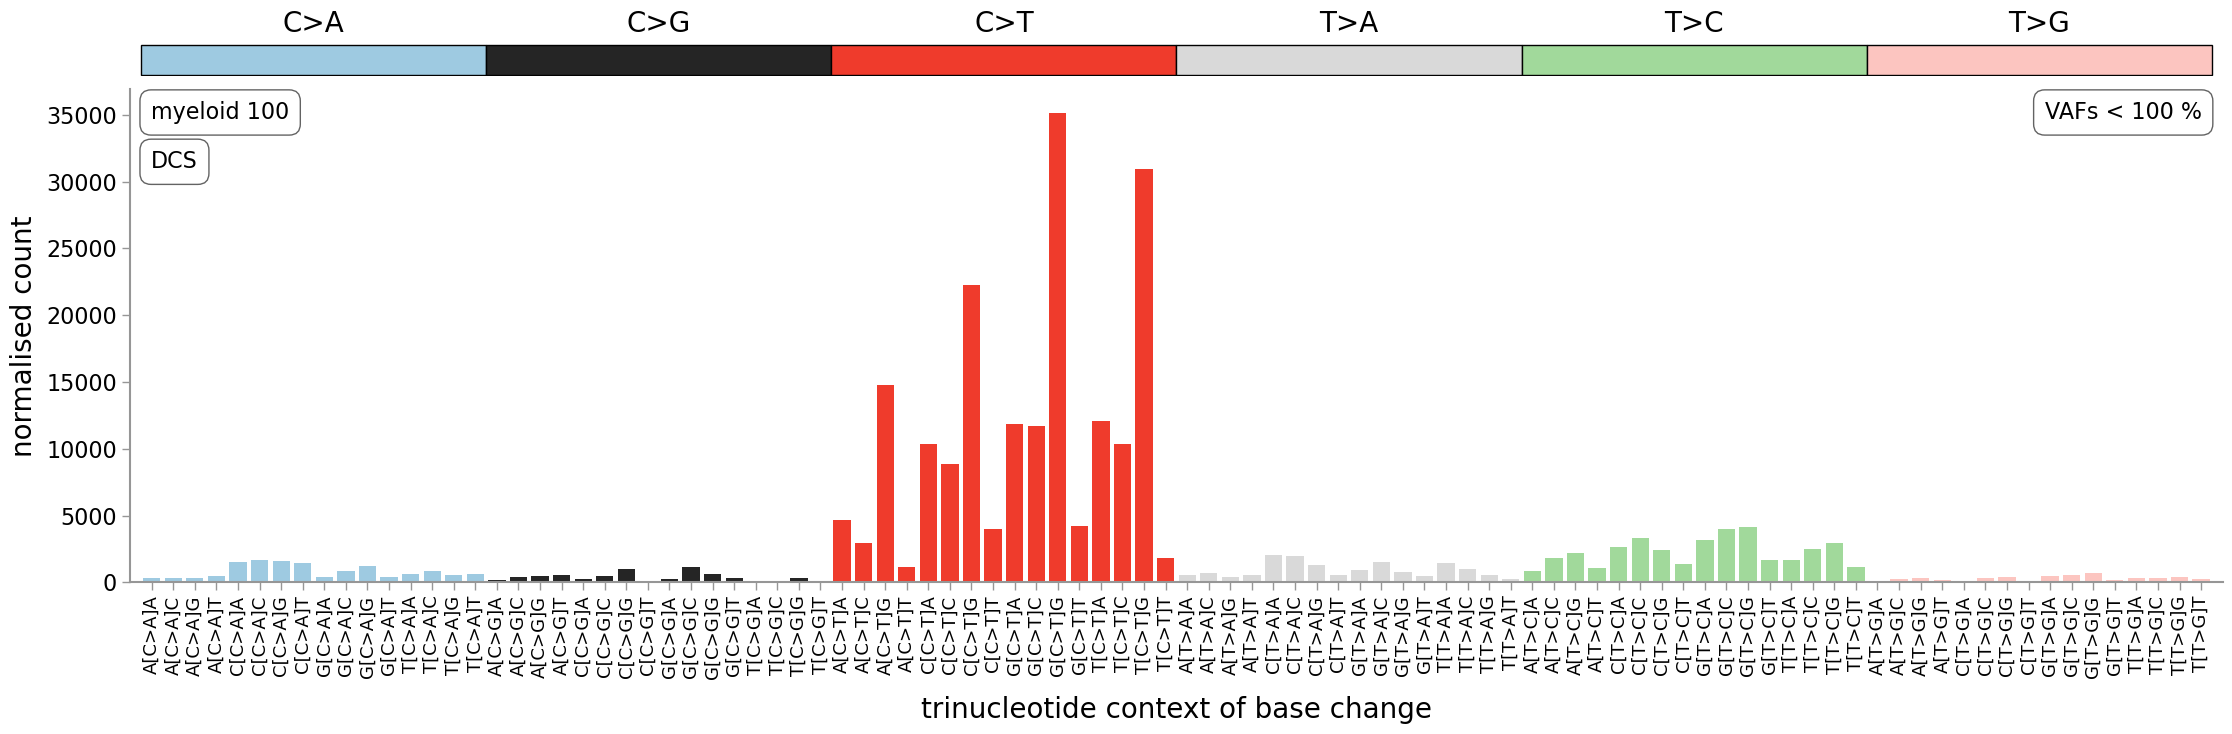

In [30]:
mutational_signature(DCS_myeloid, 'DCS', 1.0, 500, 'myeloid_100')

100% Just hDNA

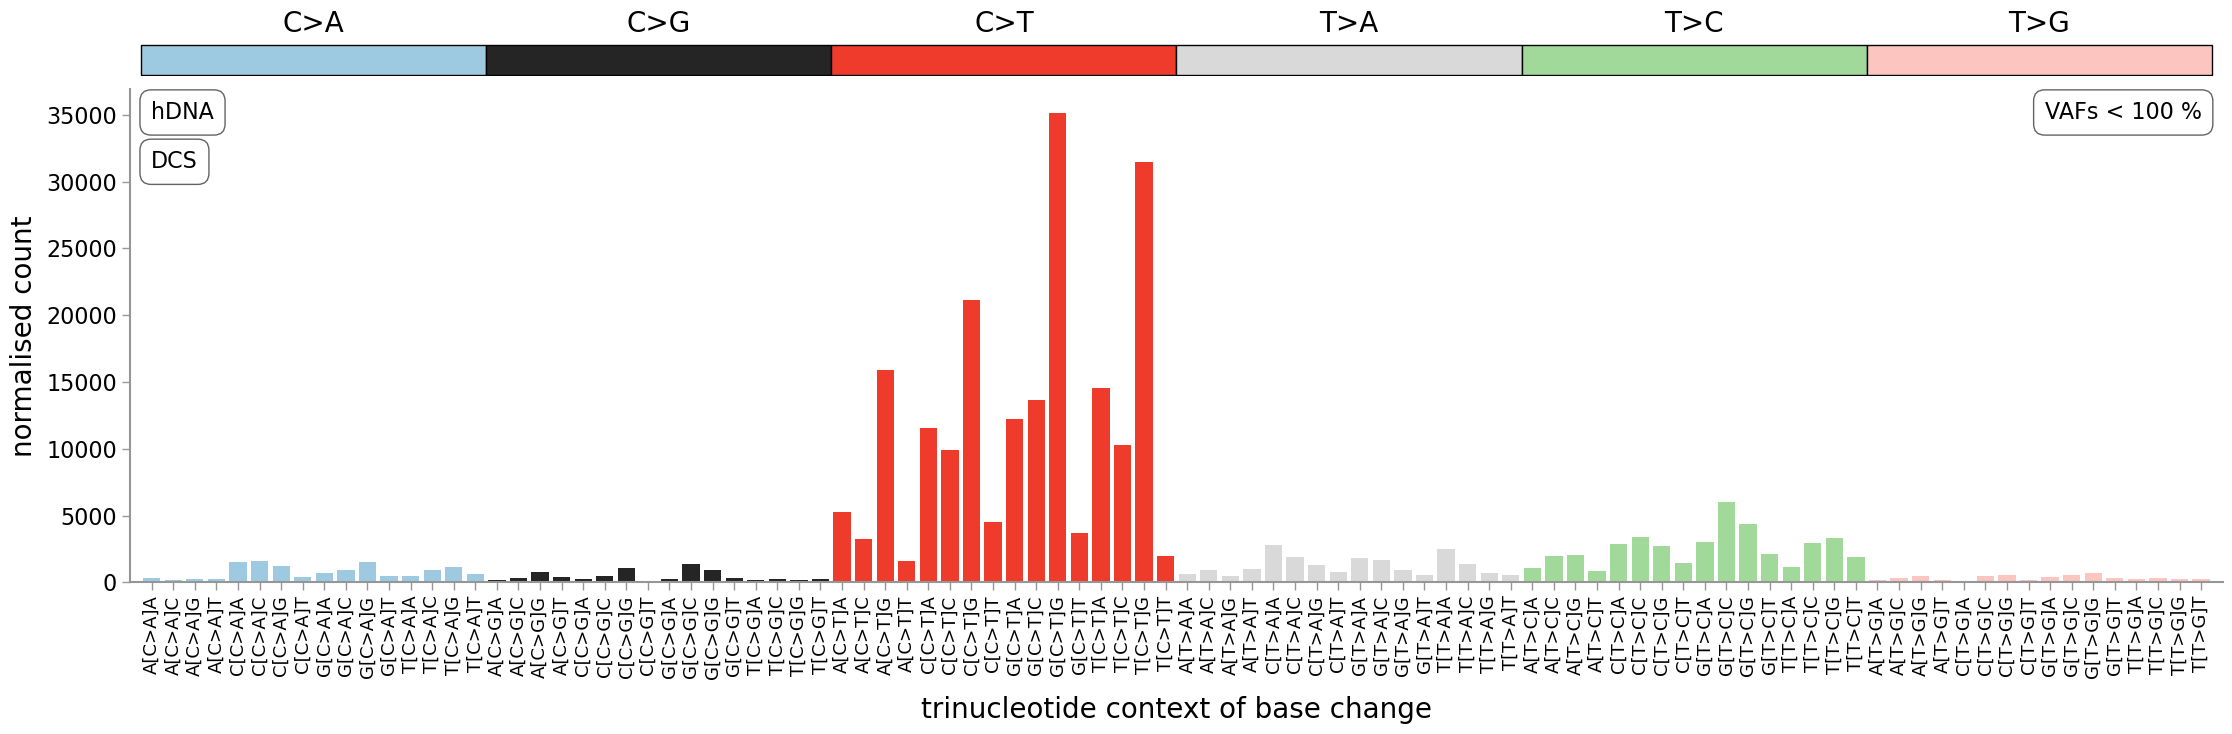

In [31]:
mutational_signature(DCS_hDNA, 'DCS', 1.0, 500, 'hDNA')